# ATAG *Waypoint 2050* — climate analysis

Post-processing of the committed scenario results for the second and third
editions. Nothing is re-computed for the figures: every series is read from
`<edition>/data_outputs/<scenario>.json`. One consistency cell re-runs a
scenario through the model and asserts the committed climate outputs still
match, which guards against silent drift on the branch.

**Scope note.** Contrail avoidance is switched off in every configuration
(`operations_contrails_start_year = 2101`), matching the scope of the reports
themselves. Contrail forcing therefore follows traffic and fuel composition
only, with no mitigation applied.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import utils
from utils import (
    COLORS, CONTRAIL_NOTE, GRID, INK_MUTED, INK_PRIMARY, INK_SECONDARY,
    MECHANISM_GROUPS, erf, load_climate, load_observed, load_vectors,
    style_axes, temperature,
)

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlecolor": INK_PRIMARY,
})

SCENARIOS = [
    ("3rd_edition_full", "s1", "3rd ed. S1"),
    ("3rd_edition_full", "s2", "3rd ed. S2"),
    ("2nd_edition_full", "s1", "2nd ed. S1"),
    ("2nd_edition_full", "s2", "2nd ed. S2"),
    ("2nd_edition_full", "s3", "2nd ed. S3"),
]

climate = {(e, s): load_climate(e, s) for e, s, _ in SCENARIOS}
LABEL = {(e, s): lab for e, s, lab in SCENARIOS}
print(f"loaded {len(climate)} scenarios, years "
      f"{climate[('3rd_edition_full', 's1')].index[0]}"
      f"-{climate[('3rd_edition_full', 's1')].index[-1]}")

loaded 5 scenarios, years 1940-2050


## Consistency check

Re-run the third-edition S1 scenario and compare its climate outputs against the
committed file. A mismatch beyond solver noise means the committed results no
longer correspond to the code on this branch.

In [2]:
import os

from aeromaps import create_process

cwd = os.getcwd()
os.chdir(utils.BASE / "3rd_edition_full")
try:
    process = create_process("./config_files/config_s1.yaml")
    process.compute()
    recomputed = process.data["climate_outputs"]
finally:
    os.chdir(cwd)

committed = climate[("3rd_edition_full", "s1")]
worst_key, worst = None, 0.0
for column in committed.columns:
    a = committed[column].to_numpy(dtype=float)
    b = recomputed[column].to_numpy(dtype=float)
    scale = max(np.nanmax(np.abs(a)), 1e-30)
    rel = np.nanmax(np.abs(a - b)) / scale
    if rel > worst:
        worst_key, worst = column, rel

print(f"worst relative difference across {len(committed.columns)} series: "
      f"{worst:.2e} ({worst_key})")
assert worst < 1e-3, f"committed results have drifted: {worst_key} off by {worst:.2e}"
print("PASS - committed climate outputs match a fresh run")

worst relative difference across 49 series: 1.80e-15 (nox_erf)
PASS - committed climate outputs match a fresh run


## Figure 1 — Aviation-attributable temperature, by forcing mechanism

The climate module resolves twelve mechanisms; they are grouped into five
families here, with the four NO$_x$ terms summed to a net contribution and soot
and sulfur summed to an aerosol term. The grouping is exact — the five families
reproduce the reported total to floating-point precision, asserted below.

Panel (a) traces the third-edition S1 scenario; panel (b) gives the 2050 split
for both third-edition scenarios with values labelled directly.

mechanism grouping closes to the reported total exactly


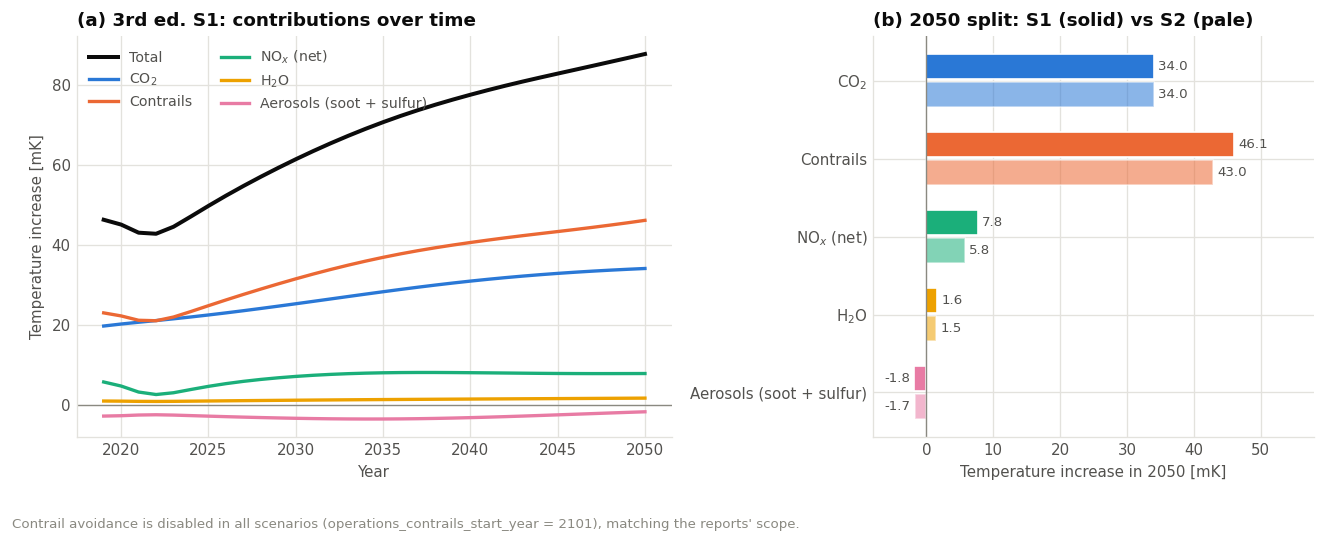

In [3]:
ED, SC = "3rd_edition_full", "s1"
df = climate[(ED, SC)]

total = df["temperature_increase_from_aviation"]
parts = {g: temperature(df, g) for g in MECHANISM_GROUPS}
assert np.allclose(sum(parts.values()), total, rtol=0, atol=1e-12), \
    "mechanism grouping does not reproduce the reported total"
print("mechanism grouping closes to the reported total exactly")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2),
                               gridspec_kw={"width_ratios": [1.35, 1]})

years = slice(2019, 2050)
ax1.plot(total.loc[years].index, 1000 * total.loc[years], color=INK_PRIMARY,
         linewidth=2.4, label="Total", zorder=5)
for g, (label, _) in MECHANISM_GROUPS.items():
    ax1.plot(parts[g].loc[years].index, 1000 * parts[g].loc[years],
             color=COLORS[g], linewidth=2, label=label)
ax1.axhline(0, color=INK_MUTED, linewidth=0.8)
style_axes(ax1, "Temperature increase [mK]")
ax1.set_title(f"(a) {LABEL[(ED, SC)]}: contributions over time", loc="left")
ax1.legend(frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY, ncol=2, loc="upper left")

pair = [("3rd_edition_full", "s1"), ("3rd_edition_full", "s2")]
groups = list(MECHANISM_GROUPS)
y = np.arange(len(groups))
height = 0.36
for i, key in enumerate(pair):
    d = climate[key]
    values = [1000 * temperature(d, g).loc[2050] for g in groups]
    offset = (i - 0.5) * height
    bars = ax2.barh(y + offset, values, height=height - 0.04,
                    color=[COLORS[g] for g in groups],
                    alpha=1.0 if i == 0 else 0.55,
                    edgecolor="white", linewidth=1.0)
    for rect, value in zip(bars, values):
        ha = "left" if value >= 0 else "right"
        pad = 0.6 if value >= 0 else -0.6
        ax2.text(value + pad, rect.get_y() + rect.get_height() / 2,
                 f"{value:.1f}", va="center", ha=ha, fontsize=8,
                 color=INK_SECONDARY)

ax2.set_yticks(y)
ax2.set_yticklabels([MECHANISM_GROUPS[g][0] for g in groups])
ax2.invert_yaxis()
ax2.axvline(0, color=INK_MUTED, linewidth=0.8)
style_axes(ax2, xlabel="Temperature increase in 2050 [mK]")
ax2.set_xlim(-8, 58)
ax2.set_title("(b) 2050 split: S1 (solid) vs S2 (pale)", loc="left")

fig.text(0.0, -0.06, CONTRAIL_NOTE, fontsize=8, color=INK_MUTED)
fig.tight_layout()
fig.savefig("fig1_temperature_decomposition.pdf")
plt.show()

### The headline

Non-CO$_2$ warming exceeds CO$_2$ warming in 2050 in every scenario, so reaching
net zero **CO$_2$** does not stabilise aviation's contribution to warming.

In [4]:
rows = []
for e, s, label in SCENARIOS:
    d = climate[(e, s)]
    co2 = d["temperature_increase_from_co2_from_aviation"].loc[2050]
    non_co2 = d["temperature_increase_from_non_co2_from_aviation"].loc[2050]
    rows.append({
        "scenario": label,
        "CO2 [mK]": 1000 * co2,
        "non-CO2 [mK]": 1000 * non_co2,
        "total [mK]": 1000 * d["temperature_increase_from_aviation"].loc[2050],
        "non-CO2 / CO2": non_co2 / co2,
    })
headline = pd.DataFrame(rows).set_index("scenario").round(3)
assert (headline["non-CO2 / CO2"] > 1).all(), "non-CO2 does not dominate in every scenario"
headline

,CO2 [mK],non-CO2 [mK],total [mK],non-CO2 / CO2
scenario,,,,
3rd ed. S1,34.037,53.650,87.687,1.576
3rd ed. S2,34.029,48.509,82.539,1.426
2nd ed. S1,33.961,48.956,82.917,1.442
2nd ed. S2,33.829,54.093,87.922,1.599
2nd ed. S3,34.236,49.287,83.522,1.440


## Figure 2 — Effective radiative forcing, and a check against Lee et al. (2021)

ERF is stored in W/m$^2$ and plotted here in mW/m$^2$ with an explicit factor of
1000. Before the trajectory is read, the historic value is validated against the
literature: Lee et al. (2021) put total aviation ERF in 2018 at
**≈100.9 mW/m$^2$**.

The marked CO$_2$ net-zero year is the point where the scenario's annual CO$_2$
emissions net of offsets reach zero. Total ERF is still climbing there, which is
the same conclusion as Figure 1 seen through the forcing rather than the
temperature response.

In [5]:
LEE_2018_TOTAL_ERF_MW = 100.9  # Lee et al. (2021), total aviation ERF in 2018

erf_2018 = 1000 * climate[("3rd_edition_full", "s1")]["total_erf"].loc[2018]
deviation = erf_2018 / LEE_2018_TOTAL_ERF_MW - 1
print(f"modelled 2018 total aviation ERF : {erf_2018:.2f} mW/m2")
print(f"Lee et al. (2021)                : {LEE_2018_TOTAL_ERF_MW:.1f} mW/m2")
print(f"deviation                        : {deviation:+.1%}")
assert abs(deviation) < 0.10, (
    f"2018 ERF is {deviation:+.1%} from Lee et al. (2021); the historic forcing "
    "is not reproduced"
)
print("PASS - historic ERF is consistent with the literature")

modelled 2018 total aviation ERF : 100.36 mW/m2
Lee et al. (2021)                : 100.9 mW/m2
deviation                        : -0.5%
PASS - historic ERF is consistent with the literature


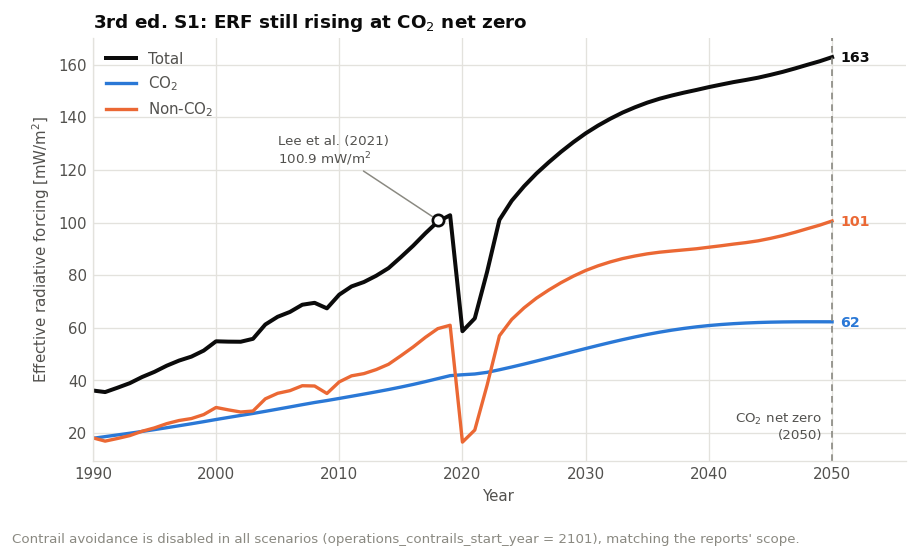

In [6]:
ED, SC = "3rd_edition_full", "s1"
d = climate[(ED, SC)]
v = load_vectors(ED, SC)

span = slice(1990, 2050)
total_erf = 1000 * d["total_erf"].loc[span]
co2_erf = 1000 * d["co2_erf"].loc[span]
non_co2_erf = 1000 * d["non_co2_erf"].loc[span]

# CO2 net zero: first year the scenario's emissions net of offsets reach zero.
# Gross CO2 lives in the climate block (it spans 1940-2050); offsets are a
# vector output, so the difference is taken over the vector index.
net_co2 = d["co2_emissions"].reindex(v.index) - v["carbon_offset"]
reached = net_co2[net_co2 <= 1e-6]
net_zero_year = int(reached.index[0]) if len(reached) else None

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(total_erf.index, total_erf, color=INK_PRIMARY, linewidth=2.4, label="Total")
ax.plot(co2_erf.index, co2_erf, color=COLORS["co2"], linewidth=2, label="CO$_2$")
ax.plot(non_co2_erf.index, non_co2_erf, color=COLORS["contrails"], linewidth=2,
        label="Non-CO$_2$")

ax.scatter([2018], [LEE_2018_TOTAL_ERF_MW], s=46, facecolor="white",
           edgecolor=INK_PRIMARY, linewidth=1.6, zorder=6)
ax.annotate("Lee et al. (2021)\n100.9 mW/m$^2$", (2018, LEE_2018_TOTAL_ERF_MW),
            textcoords="offset points", xytext=(-96, 34), fontsize=8,
            color=INK_SECONDARY, ha="left",
            arrowprops=dict(arrowstyle="-", color=INK_MUTED, linewidth=0.9,
                            shrinkA=0, shrinkB=4))

if net_zero_year:
    ax.axvline(net_zero_year, color=INK_MUTED, linewidth=1, linestyle=(0, (4, 3)))
    ax.annotate(f"CO$_2$ net zero\n({net_zero_year})", (net_zero_year, ax.get_ylim()[0]),
                textcoords="offset points", xytext=(-6, 12), fontsize=8,
                color=INK_SECONDARY, ha="right", va="bottom")

for series, colour in ((total_erf, INK_PRIMARY), (co2_erf, COLORS["co2"]),
                       (non_co2_erf, COLORS["contrails"])):
    ax.annotate(f"{series.loc[2050]:.0f}", (2050, series.loc[2050]),
                textcoords="offset points", xytext=(5, -3), fontsize=8.5,
                color=colour, fontweight="semibold")

style_axes(ax, "Effective radiative forcing [mW/m$^2$]")
ax.set_title(f"{LABEL[(ED, SC)]}: ERF still rising at CO$_2$ net zero", loc="left")
ax.legend(frameon=False, fontsize=9, labelcolor=INK_SECONDARY, loc="upper left")
ax.set_xlim(1990, 2056)
fig.text(0.0, -0.04, CONTRAIL_NOTE, fontsize=8, color=INK_MUTED)
fig.tight_layout()
fig.savefig("fig2_erf_trajectory.pdf")
plt.show()

## Figure 3 — Observed versus reproduced traffic, 2019–2024

The scenarios take observed traffic through 2023 and predict from 2024 onwards,
so 2024 is the first genuinely forecast year. Plotting it against the A4A/ICAO
observations shows how much of the recovery is data and how much is model.

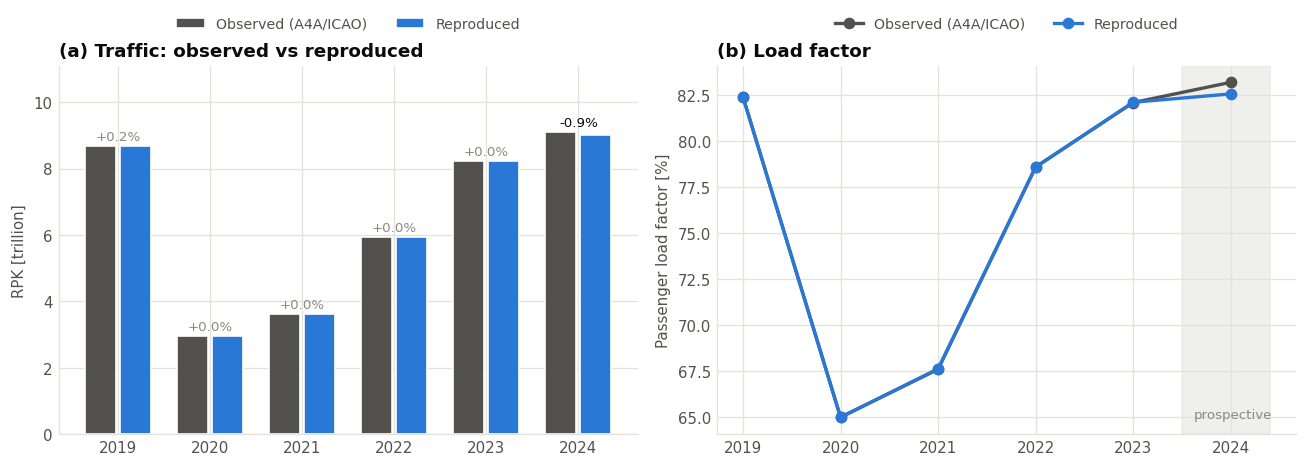

worst |error| over the observed years 2020-2023 : 2.22e-16
first prospective year (2024) error       : -0.89%


In [7]:
observed = load_observed()
v = load_vectors("3rd_edition_full", "s1")
years = list(range(2019, 2025))

model_rpk = v["rpk"].reindex(years)
obs_rpk = observed["rpk"].reindex(years)
model_lf = 100 * v["rpk"].reindex(years) / v["ask"].reindex(years)
obs_lf = observed["load_factor"].reindex(years)

boundary = 2024  # first prospective year

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.0))
width = 0.38
x = np.arange(len(years))
ax1.bar(x - width / 2, obs_rpk / 1e12, width - 0.04, color=INK_SECONDARY,
        edgecolor="white", linewidth=1.0, label="Observed (A4A/ICAO)")
ax1.bar(x + width / 2, model_rpk / 1e12, width - 0.04, color=COLORS["co2"],
        edgecolor="white", linewidth=1.0, label="Reproduced")
for i, year in enumerate(years):
    if np.isfinite(obs_rpk.iloc[i]) and obs_rpk.iloc[i]:
        gap = model_rpk.iloc[i] / obs_rpk.iloc[i] - 1
        ax1.text(i, max(obs_rpk.iloc[i], model_rpk.iloc[i]) / 1e12 + 0.18,
                 f"{gap:+.1%}", ha="center", fontsize=8,
                 color=INK_PRIMARY if year >= boundary else INK_MUTED)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
style_axes(ax1, "RPK [trillion]", xlabel=None)
ax1.set_ylim(0, 1.22 * float(np.nanmax(obs_rpk) / 1e12))
ax1.set_title("(a) Traffic: observed vs reproduced", loc="left")
ax1.legend(frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY,
           loc="lower center", bbox_to_anchor=(0.5, 1.06), ncol=2)

ax2.plot(years, obs_lf, color=INK_SECONDARY, linewidth=2, marker="o",
         markersize=6, label="Observed (A4A/ICAO)")
ax2.plot(years, model_lf, color=COLORS["co2"], linewidth=2, marker="o",
         markersize=6, label="Reproduced")
ax2.axvspan(boundary - 0.5, years[-1] + 0.4, color=GRID, alpha=0.55, zorder=0)
style_axes(ax2, "Passenger load factor [%]", xlabel=None)
ax2.annotate("prospective", (boundary - 0.45, ax2.get_ylim()[0]),
             textcoords="offset points", xytext=(4, 8), fontsize=8,
             color=INK_MUTED, va="bottom")
ax2.set_title("(b) Load factor", loc="left")
ax2.legend(frameon=False, fontsize=8.5, labelcolor=INK_SECONDARY,
           loc="lower center", bbox_to_anchor=(0.5, 1.06), ncol=2)

fig.tight_layout()
fig.savefig("fig3_traffic_validation.pdf")
plt.show()

historic = [y for y in years if y < boundary]
worst_historic = max(abs(model_rpk.loc[y] / obs_rpk.loc[y] - 1)
                     for y in historic if y >= 2020)
print(f"worst |error| over the observed years 2020-2023 : {worst_historic:.2e}")
print(f"first prospective year ({boundary}) error       : "
      f"{model_rpk.loc[boundary] / obs_rpk.loc[boundary] - 1:+.2%}")
assert worst_historic < 1e-9, "observed years are not reproduced exactly"

## Table — 2050 temperature by mechanism and scenario

The full twelve-way split, in mK. The editions renamed and swapped their
scenarios: the third edition's S1 descends from the second edition's S2 and
vice-versa, so analogous scenarios are paired explicitly rather than by name.
The pairing is asserted, not assumed.

In [8]:
MECHANISMS = [
    ("CO2", "co2"), ("Contrails", "contrails"),
    ("NOx: short-term O3 increase", "nox_short_term_o3_increase"),
    ("NOx: long-term O3 decrease", "nox_long_term_o3_decrease"),
    ("NOx: CH4 decrease", "nox_ch4_decrease"),
    ("NOx: strat. water vapour decrease", "nox_stratospheric_water_vapor_decrease"),
    ("H2O", "h2o"), ("Soot", "soot"), ("Sulfur", "sulfur"),
]

table = pd.DataFrame(
    {LABEL[(e, s)]: {
        name: 1000 * climate[(e, s)][f"temperature_increase_from_{key}_from_aviation"].loc[2050]
        for name, key in MECHANISMS
    } for e, s, _ in SCENARIOS}
)
table.loc["Total"] = [1000 * climate[(e, s)]["temperature_increase_from_aviation"].loc[2050]
                      for e, s, _ in SCENARIOS]
display(table.round(3))

,3rd ed. S1,3rd ed. S2,2nd ed. S1,2nd ed. S2,2nd ed. S3
CO2,34.037,34.029,33.961,33.829,34.236
Contrails,46.080,42.959,43.161,45.697,45.308
NOx: short-term O3 increase,39.880,36.956,37.557,41.675,35.471
NOx: long-term O3 decrease,-9.731,-9.441,-9.556,-10.064,-9.419
NOx: CH4 decrease,-19.463,-18.882,-19.112,-20.127,-18.837
NOx: strat. water vapour decrease,-2.919,-2.832,-2.867,-3.019,-2.826
H2O,1.611,1.493,1.517,1.684,1.433
Soot,0.373,0.353,0.356,0.374,0.358
Sulfur,-2.179,-2.097,-2.101,-2.127,-2.202
Total,87.687,82.539,82.917,87.922,83.522


In [9]:
deltas = {}
for third, second in utils.ANALOGOUS.items():
    a, b = climate[third], climate[second]
    deltas[f"{LABEL[third]} - {LABEL[second]}"] = {
        name: 1000 * (a[f"temperature_increase_from_{key}_from_aviation"].loc[2050]
                      - b[f"temperature_increase_from_{key}_from_aviation"].loc[2050])
        for name, key in MECHANISMS
    }
delta_table = pd.DataFrame(deltas)
delta_table.loc["Total"] = [
    1000 * (climate[t]["temperature_increase_from_aviation"].loc[2050]
            - climate[s]["temperature_increase_from_aviation"].loc[2050])
    for t, s in utils.ANALOGOUS.items()
]

# The pairing claim: each third-edition scenario is closer to its stated
# second-edition counterpart than to the other one.
for third, second in utils.ANALOGOUS.items():
    other = next(v for k, v in utils.ANALOGOUS.items() if k != third)
    t = climate[third]["temperature_increase_from_aviation"].loc[2050]
    near = abs(t - climate[second]["temperature_increase_from_aviation"].loc[2050])
    far = abs(t - climate[other]["temperature_increase_from_aviation"].loc[2050])
    assert near < far, (
        f"{LABEL[third]} is closer to {LABEL[other]} than to {LABEL[second]}; "
        "the cross-edition pairing does not hold"
    )
print("PASS - cross-edition scenario pairing holds (3rd S1 <-> 2nd S2, 3rd S2 <-> 2nd S1)")
display(delta_table.round(3))

PASS - cross-edition scenario pairing holds (3rd S1 <-> 2nd S2, 3rd S2 <-> 2nd S1)


,3rd ed. S1 - 2nd ed. S2,3rd ed. S2 - 2nd ed. S1
CO2,0.207,0.068
Contrails,0.383,-0.202
NOx: short-term O3 increase,-1.796,-0.601
NOx: long-term O3 decrease,0.332,0.115
NOx: CH4 decrease,0.664,0.230
NOx: strat. water vapour decrease,0.100,0.035
H2O,-0.073,-0.024
Soot,-0.002,-0.003
Sulfur,-0.052,0.004
Total,-0.236,-0.378
